# **Eksperimen Machine Learning — Samuel Sitompul**

**Dataset**: Loan Approval Prediction  
**Sumber**: Kaggle — Loan Approval Prediction Dataset  
**Tujuan**: Membangun model klasifikasi untuk memprediksi apakah pengajuan pinjaman disetujui atau ditolak.

# **1. Perkenalan Dataset**

Dataset **Loan Approval Prediction** berisi data historis pengajuan pinjaman bank beserta hasilnya (Approved/Rejected). Dataset ini mencakup:

- **Jumlah data**: 4.269 baris
- **Jumlah fitur**: 12 kolom + 1 target
- **Sumber**: [Kaggle — Loan Approval Prediction](https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset)

**Deskripsi kolom:**
| Kolom | Tipe | Deskripsi |
|---|---|---|
| loan_id | int | ID unik pinjaman (tidak digunakan untuk model) |
| no_of_dependents | int | Jumlah tanggungan pemohon (0–5) |
| education | str | Pendidikan (Graduate / Not Graduate) |
| self_employed | str | Status pekerjaan (Yes / No) |
| income_annum | int | Pendapatan tahunan (Rupee) |
| loan_amount | int | Jumlah pinjaman yang diminta |
| loan_term | int | Jangka waktu pinjaman (tahun) |
| cibil_score | int | Skor kredit CIBIL (300–900) |
| residential_assets_value | int | Nilai aset residensial |
| commercial_assets_value | int | Nilai aset komersial |
| luxury_assets_value | int | Nilai aset mewah |
| bank_asset_value | int | Nilai aset di bank |
| loan_status | str | **TARGET**: Approved / Rejected |

# **2. Import Library**

In [1]:
# Library dasar
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Evaluasi
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

print('Library berhasil di-import!')
print(f'Pandas version  : {pd.__version__}')
print(f'NumPy version   : {np.__version__}')

Library berhasil di-import!
Pandas version  : 2.2.2
NumPy version   : 2.0.2


# **3. Memuat Dataset**

In [2]:
# Load dataset
df = pd.read_csv('/content/loan_approval_dataset_raw.csv')

# Bersihkan whitespace di nama kolom dan nilai string
df.columns = df.columns.str.strip()
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

print(f'Shape dataset  : {df.shape}')
print(f'Kolom          : {df.columns.tolist()}')
df.head()

Shape dataset  : (4269, 13)
Kolom          : ['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
# Informasi tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [4]:
# Statistik deskriptif
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita akan memahami karakteristik dataset melalui:
1. Distribusi variabel target
2. Distribusi fitur numerik
3. Hubungan antar fitur (korelasi)
4. Analisis fitur kategorikal

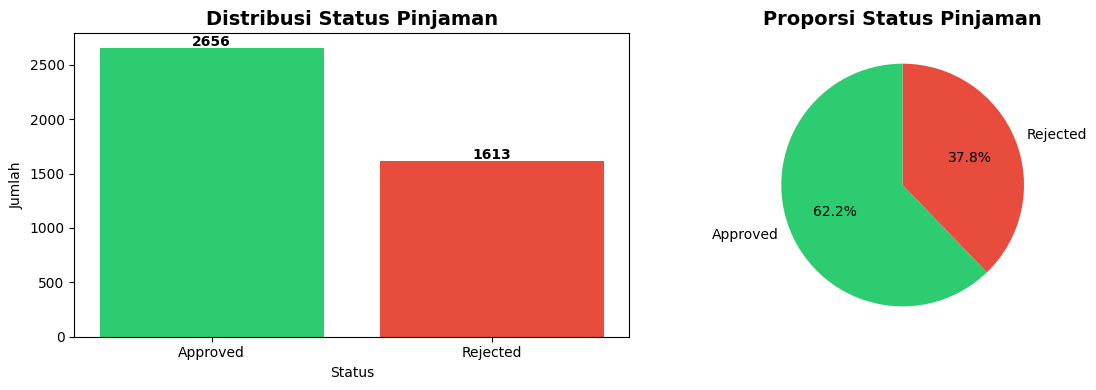

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [5]:
# ── 4.1 Distribusi Target ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
loan_counts = df['loan_status'].value_counts()
axes[0].bar(loan_counts.index, loan_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribusi Status Pinjaman', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah')
for i, (k, v) in enumerate(loan_counts.items()):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    loan_counts.values,
    labels=loan_counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
axes[1].set_title('Proporsi Status Pinjaman', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print(loan_counts)

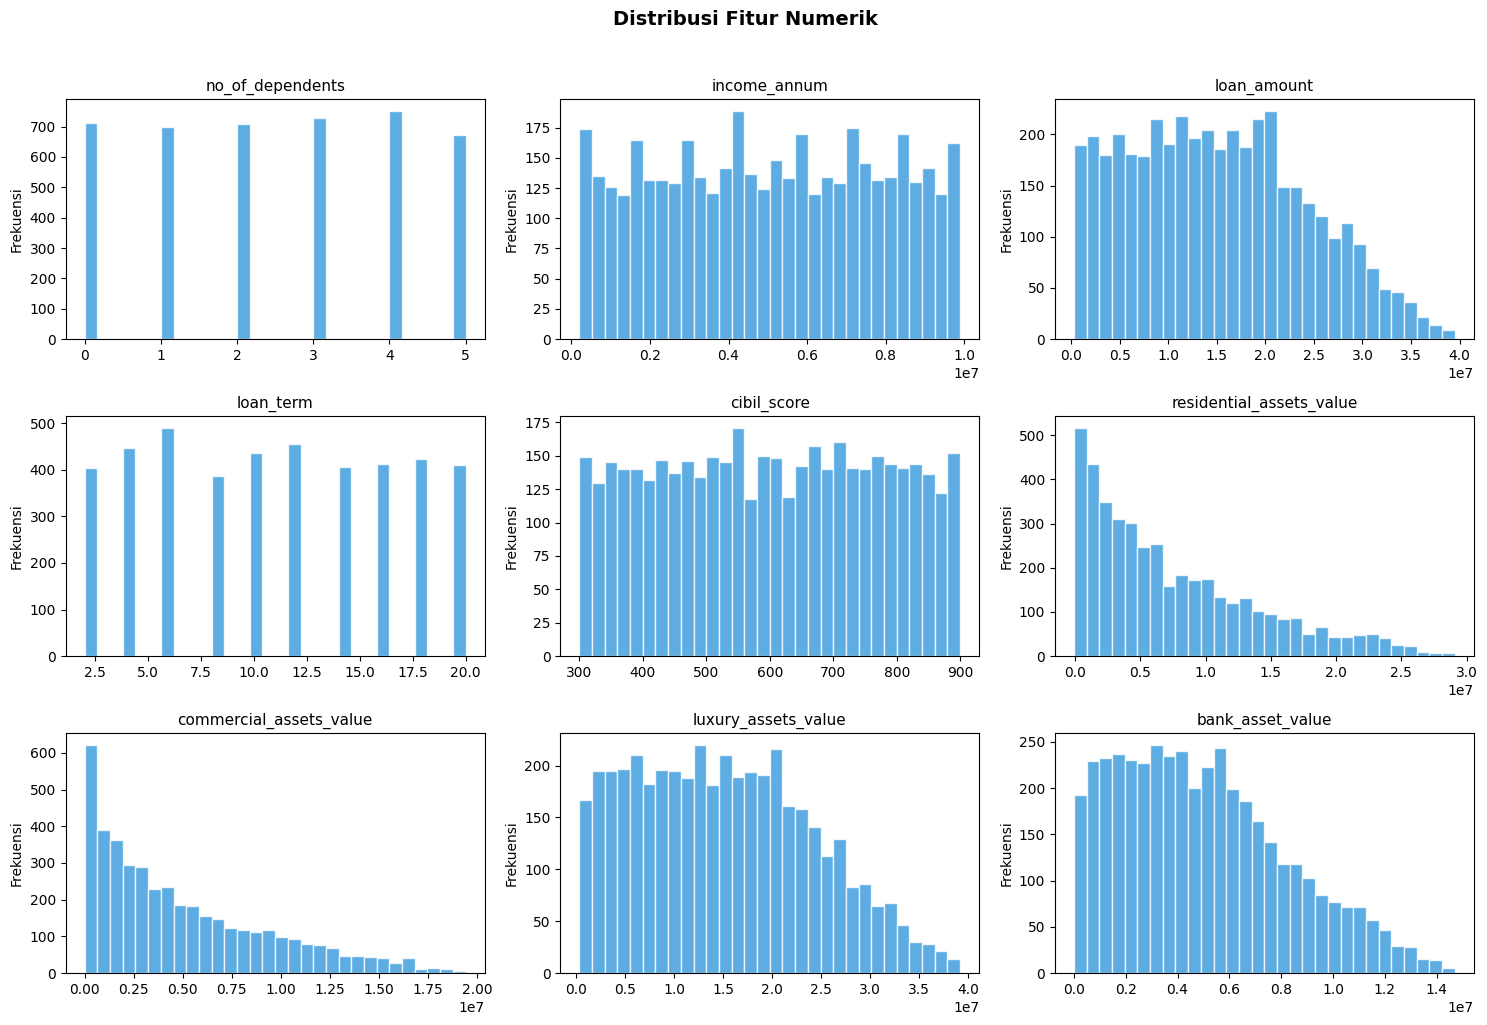

In [6]:
# ── 4.2 Distribusi Fitur Numerik ─────────────────────────────────────────────
num_cols = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
            'cibil_score', 'residential_assets_value',
            'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_numeric_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

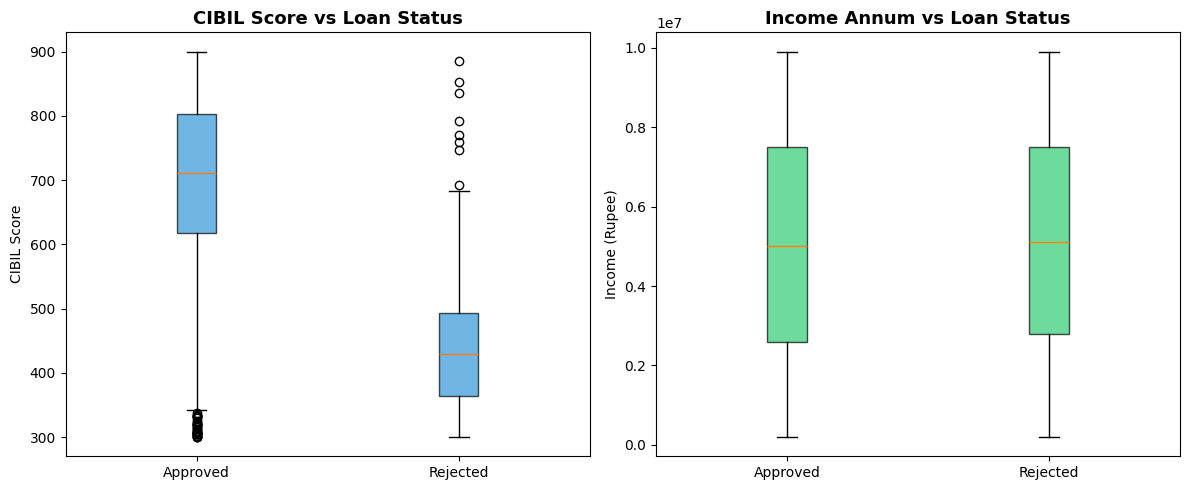

In [7]:
# ── 4.3 Boxplot: CIBIL Score vs Loan Status ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CIBIL Score
approved = df[df['loan_status'] == 'Approved']['cibil_score']
rejected = df[df['loan_status'] == 'Rejected']['cibil_score']
axes[0].boxplot([approved, rejected], labels=['Approved', 'Rejected'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[0].set_title('CIBIL Score vs Loan Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('CIBIL Score')

# Income vs Status
approved_inc = df[df['loan_status'] == 'Approved']['income_annum']
rejected_inc = df[df['loan_status'] == 'Rejected']['income_annum']
axes[1].boxplot([approved_inc, rejected_inc], labels=['Approved', 'Rejected'],
                patch_artist=True,
                boxprops=dict(facecolor='#2ecc71', alpha=0.7))
axes[1].set_title('Income Annum vs Loan Status', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Income (Rupee)')

plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()

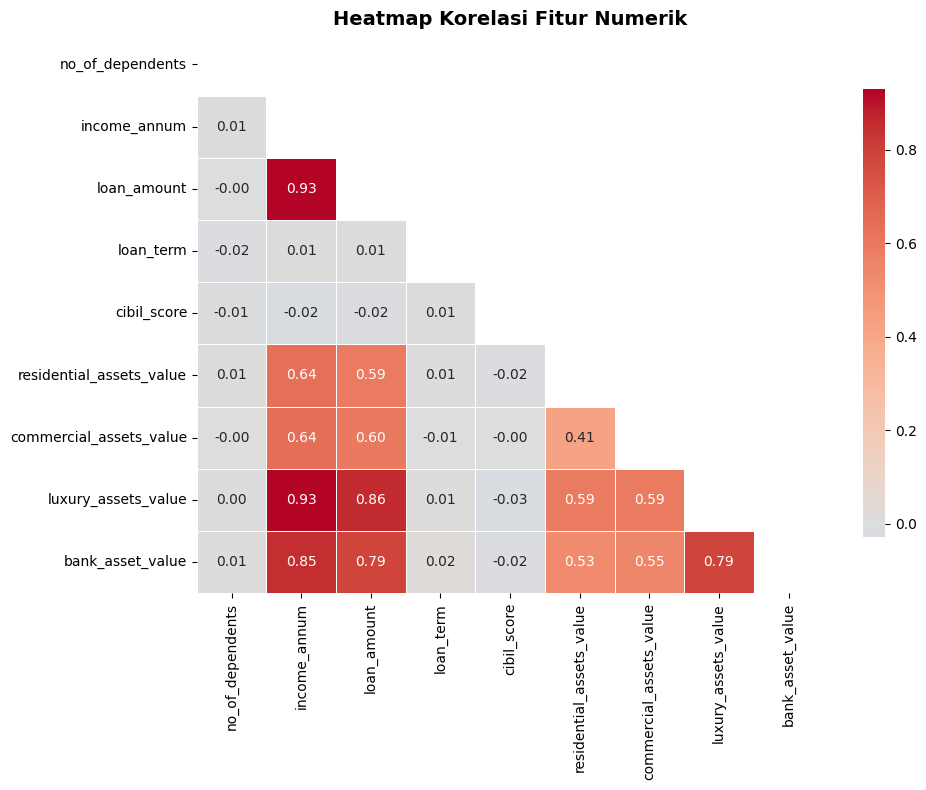

In [8]:
# ── 4.4 Korelasi antar Fitur Numerik ─────────────────────────────────────────
df_temp = df[num_cols].copy()

plt.figure(figsize=(10, 8))
corr_matrix = df_temp.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

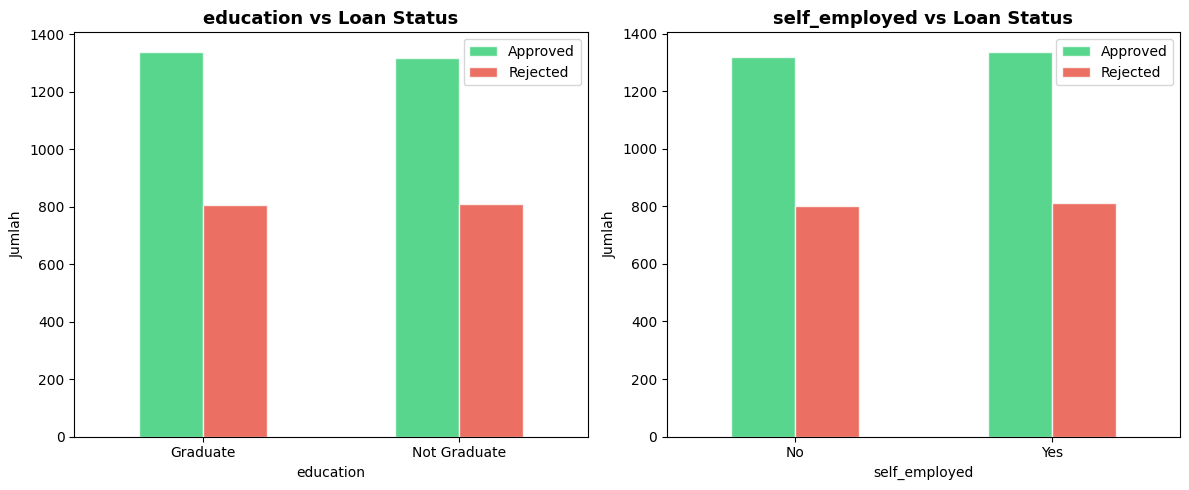

In [9]:
# ── 4.5 Fitur Kategorikal ────────────────────────────────────────────────────
cat_cols = ['education', 'self_employed']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_map = {'Approved': '#2ecc71', 'Rejected': '#e74c3c'}

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['loan_status'])
    ct.plot(kind='bar', ax=axes[i], color=[colors_map['Approved'], colors_map['Rejected']],
            edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col} vs Loan Status', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(['Approved', 'Rejected'])

plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
# ── 4.6 Missing Values & Duplikat ────────────────────────────────────────────
print('=== Cek Missing Values ===')
print(df.isnull().sum())

print(f'\n=== Cek Duplikat ===')
print(f'Jumlah duplikat: {df.duplicated().sum()}')

print('\nKesimpulan: Dataset sangat bersih, tidak ada missing values maupun duplikat.')

=== Cek Missing Values ===
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

=== Cek Duplikat ===
Jumlah duplikat: 0

Kesimpulan: Dataset sangat bersih, tidak ada missing values maupun duplikat.


# **5. Data Preprocessing**

Tahapan preprocessing yang dilakukan:
1. **Menghapus kolom tidak relevan** (`loan_id`)
2. **Encoding kategorikal** — LabelEncoder untuk `education`, `self_employed`, `loan_status`
3. **Standarisasi fitur numerik** — StandardScaler
4. **Train-Test Split** — 80% train, 20% test
5. **Simpan hasil** ke CSV

In [11]:
# ── 5.1 Drop kolom tidak relevan ─────────────────────────────────────────────
df_clean = df.copy()
df_clean = df_clean.drop(columns=['loan_id'])
print(f'Shape setelah drop loan_id: {df_clean.shape}')
df_clean.head(3)

Shape setelah drop loan_id: (4269, 12)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected


In [12]:
# ── 5.2 Label Encoding ────────────────────────────────────────────────────────
label_encoders = {}
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Kolom kategorikal: {cat_cols}')

for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

df_clean.head(3)

Kolom kategorikal: ['education', 'self_employed', 'loan_status']
  education: {'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}
  self_employed: {'No': np.int64(0), 'Yes': np.int64(1)}
  loan_status: {'Approved': np.int64(0), 'Rejected': np.int64(1)}


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1


In [13]:
# ── 5.3 Standarisasi Fitur Numerik ────────────────────────────────────────────
TARGET_COL = 'loan_status'
num_cols_to_scale = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols_to_scale = [c for c in num_cols_to_scale if c != TARGET_COL]
print(f'Kolom yang di-scale: {num_cols_to_scale}')

scaler = StandardScaler()
df_clean[num_cols_to_scale] = scaler.fit_transform(df_clean[num_cols_to_scale])

print('\nStatistik setelah scaling:')
df_clean[num_cols_to_scale].describe().round(3)

Kolom yang di-scale: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

Statistik setelah scaling:


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000,4269.000,4269.000,4269.000,4269.000,4269.000,4269.000,4269.000,4269.000,4269.000,4269.000
mean,0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.474,-0.996,-1.007,-1.731,-1.640,-1.559,-1.740,-1.165,-1.133,-1.629,-1.531
25%,-0.884,-0.996,-1.007,-0.841,-0.822,-0.858,-0.852,-0.811,-0.837,-0.838,-0.824
50%,0.296,-0.996,0.993,0.015,-0.070,-0.158,0.000,-0.288,-0.290,-0.058,-0.116
75%,0.885,1.004,0.993,0.870,0.704,0.893,0.859,0.589,0.599,0.722,0.653
max,1.475,1.004,0.993,1.725,2.695,1.594,1.740,3.326,3.287,2.645,2.992


In [14]:
# ── 5.4 Train-Test Split ──────────────────────────────────────────────────────
X = df_clean.drop(columns=[TARGET_COL])
y = df_clean[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train distribusi: {y_train.value_counts().to_dict()}')
print(f'y_test distribusi : {y_test.value_counts().to_dict()}')

X_train: (3415, 11)  |  X_test: (854, 11)
y_train distribusi: {0: 2125, 1: 1290}
y_test distribusi : {0: 531, 1: 323}


In [15]:
# ── 5.5 Simpan Hasil Preprocessing ───────────────────────────────────────────
output_path = 'loan_approval_dataset_preprocessing.csv'
df_clean.to_csv(output_path, index=False)
print(f'Dataset preprocessing berhasil disimpan ke: {output_path}')
print(f'Shape: {df_clean.shape}')
df_clean.head()

Dataset preprocessing berhasil disimpan ke: loan_approval_dataset_preprocessing.csv
Shape: (4269, 12)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,-0.294102,-0.995559,-1.007288,1.617979,1.633052,0.192617,1.032792,-0.780058,2.877289,0.832028,0.930304,0
1,-1.473548,1.004461,0.992765,-0.341750,-0.324414,-0.508091,-1.061051,-0.733924,-0.631921,-0.694993,-0.515936,1
2,0.295621,-0.995559,-1.007288,1.439822,1.610933,1.594031,-0.544840,-0.057300,-0.107818,1.996520,2.407316,1
3,0.295621,-0.995559,-1.007288,1.119139,1.721525,-0.508091,-0.771045,1.649637,-0.381263,0.897943,0.899533,1
4,1.475067,1.004461,0.992765,1.689242,1.002681,1.594031,-1.264055,0.757724,0.735304,1.568075,0.007172,1


# **Kesimpulan Eksperimen**

Dataset **Loan Approval Prediction** telah berhasil diproses melalui tahapan:

| Tahapan | Detail |
|---|---|
| Data Loading | CSV berhasil dimuat, 4269 baris × 13 kolom |
| EDA | Distribusi target seimbang (62%/38%), CIBIL Score adalah fitur paling diskriminatif |
| Drop kolom | `loan_id` dihapus |
| Label Encoding | `education`, `self_employed`, `loan_status` |
| Standarisasi | StandardScaler pada 9 fitur numerik |
| Split | 80% train (3415), 20% test (854) |
| Output | `loan_approval_dataset_preprocessing.csv` (4269 × 12) |

Dataset siap digunakan untuk pelatihan model machine learning.